In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics

In [3]:
df = pd.read_csv('data/housing.csv')

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
cols = ['price', 'area']
data = df[cols]

In [8]:
data.isna().sum()

price    0
area     0
dtype: int64

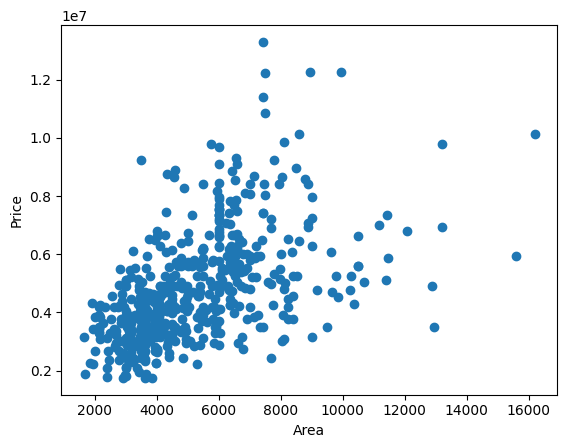

In [9]:
plt.scatter(data['area'], data['price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

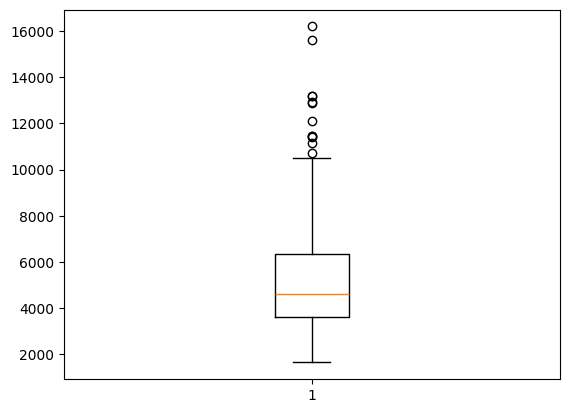

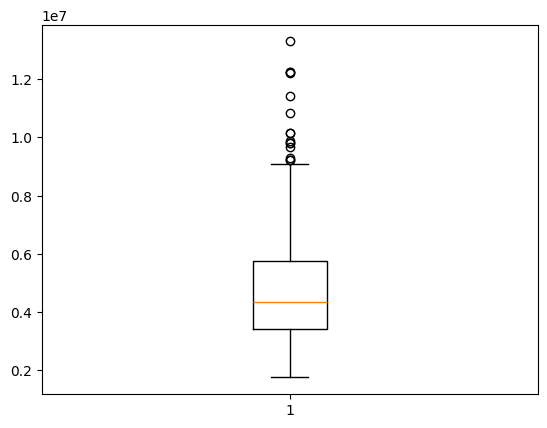

In [10]:
plt.boxplot(data['area'])
plt.show()

plt.boxplot(data['price'])
plt.show()

In [11]:
statistics.correlation(data['area'], data['price'])

0.5359973457780801

In [12]:
from sklearn.model_selection import train_test_split

x = data['area'].values.reshape(-1, 1)
y = data['price'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(x_train, y_train)

m = lin_reg.coef_
b = lin_reg.intercept_

print(f'{m=}')
print(f'{b=}')

m=array([425.72984194])
b=np.float64(2512254.2639593435)


In [14]:
y_pred = lin_reg.predict(x_test)

In [15]:
mse = np.mean((y_test - y_pred) ** 2)

In [16]:
mae = np.mean(abs(y_test - y_pred))

In [17]:
r2 = lin_reg.score(x_test, y_test)

In [18]:
print(f"{mse=}")
print(f"{mae=}")
print(f"{r2=}")

mse=np.float64(3675286604768.185)
mae=np.float64(1474748.1337969352)
r2=0.27287851871974644


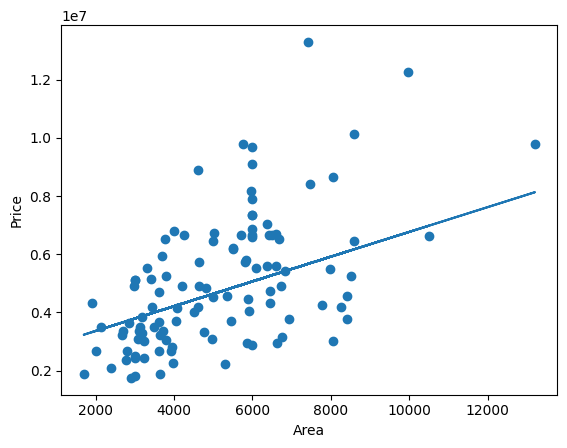

In [19]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred)
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [20]:
sq_ft_1000 = lin_reg.predict([[1000]])
print(f"Price = {sq_ft_1000}")

Price = [2937984.10589813]
